# Crime classification using supervised machine learning in San Francisco

Se están corriendo 1000 samples ya que el ram de la sesión se consume rápido.

In [128]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report

In [101]:
train_dataset_filename = 'train.csv'
test_dataset_filename = 'test.csv'

In [102]:
train_df = pd.read_csv(train_dataset_filename).head(1000)
train_df

,Dates,Category,Descript,DayOfWeek,PdDistrict,Resolution,Address,X,Y
0,2015-05-13 23:53:00,WARRANTS,WARRANT ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",OAK ST / LAGUNA ST,-122.425892,37.774599
1,2015-05-13 23:53:00,OTHER OFFENSES,TRAFFIC VIOLATION ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",OAK ST / LAGUNA ST,-122.425892,37.774599
2,2015-05-13 23:33:00,OTHER OFFENSES,TRAFFIC VIOLATION ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",VANNESS AV / GREENWICH ST,-122.424363,37.800414
3,2015-05-13 23:30:00,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Wednesday,NORTHERN,NONE,1500 Block of LOMBARD ST,-122.426995,37.800873
4,2015-05-13 23:30:00,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Wednesday,PARK,NONE,100 Block of BRODERICK ST,-122.438738,37.771541
...,...,...,...,...,...,...,...,...,...
995,2015-05-11 11:00:00,FRAUD,FRAUDULENT CREDIT APPLICATION,Monday,MISSION,NONE,400 Block of DOLORES ST,-122.426341,37.762579
996,2015-05-11 11:00:00,FRAUD,"CREDIT CARD, THEFT BY USE OF",Monday,MISSION,NONE,400 Block of DOLORES ST,-122.426341,37.762579
997,2015-05-11 11:00:00,LARCENY/THEFT,PETTY THEFT OF PROPERTY,Monday,RICHMOND,NONE,3200 Block of BALBOA ST,-122.493588,37.775941
998,2015-05-11 11:00:00,MISSING PERSON,MISSING JUVENILE,Monday,INGLESIDE,NONE,200 Block of CAYUGA AV,-122.433422,37.730390


In [103]:
test_df = pd.read_csv(test_dataset_filename).head(1000)
test_df

,Id,Dates,DayOfWeek,PdDistrict,Address,X,Y
0,0,2015-05-10 23:59:00,Sunday,BAYVIEW,2000 Block of THOMAS AV,-122.399588,37.735051
1,1,2015-05-10 23:51:00,Sunday,BAYVIEW,3RD ST / REVERE AV,-122.391523,37.732432
2,2,2015-05-10 23:50:00,Sunday,NORTHERN,2000 Block of GOUGH ST,-122.426002,37.792212
3,3,2015-05-10 23:45:00,Sunday,INGLESIDE,4700 Block of MISSION ST,-122.437394,37.721412
4,4,2015-05-10 23:45:00,Sunday,INGLESIDE,4700 Block of MISSION ST,-122.437394,37.721412
...,...,...,...,...,...,...,...
995,995,2015-05-08 12:22:00,Friday,SOUTHERN,800 Block of MARKET ST,-122.407634,37.784189
996,996,2015-05-08 12:22:00,Friday,SOUTHERN,800 Block of MARKET ST,-122.407634,37.784189
997,997,2015-05-08 12:22:00,Friday,NORTHERN,MCALLISTER ST / STEINER ST,-122.433407,37.778423
998,998,2015-05-08 12:04:00,Friday,MISSION,13TH ST / SOUTH VAN NESS AV,-122.417757,37.769814


In [104]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Dates       1000 non-null   object 
 1   Category    1000 non-null   object 
 2   Descript    1000 non-null   object 
 3   DayOfWeek   1000 non-null   object 
 4   PdDistrict  1000 non-null   object 
 5   Resolution  1000 non-null   object 
 6   Address     1000 non-null   object 
 7   X           1000 non-null   float64
 8   Y           1000 non-null   float64
dtypes: float64(2), object(7)
memory usage: 70.4+ KB


In [105]:
train_df.isnull().sum()

,0
Dates,0
Category,0
Descript,0
DayOfWeek,0
PdDistrict,0
Resolution,0
Address,0
X,0
Y,0


In [106]:
train_df['Category'].value_counts()

,count
Category,
LARCENY/THEFT,286
OTHER OFFENSES,119
NON-CRIMINAL,109
ASSAULT,77
VEHICLE THEFT,69
BURGLARY,50
VANDALISM,45
WARRANTS,43
MISSING PERSON,34


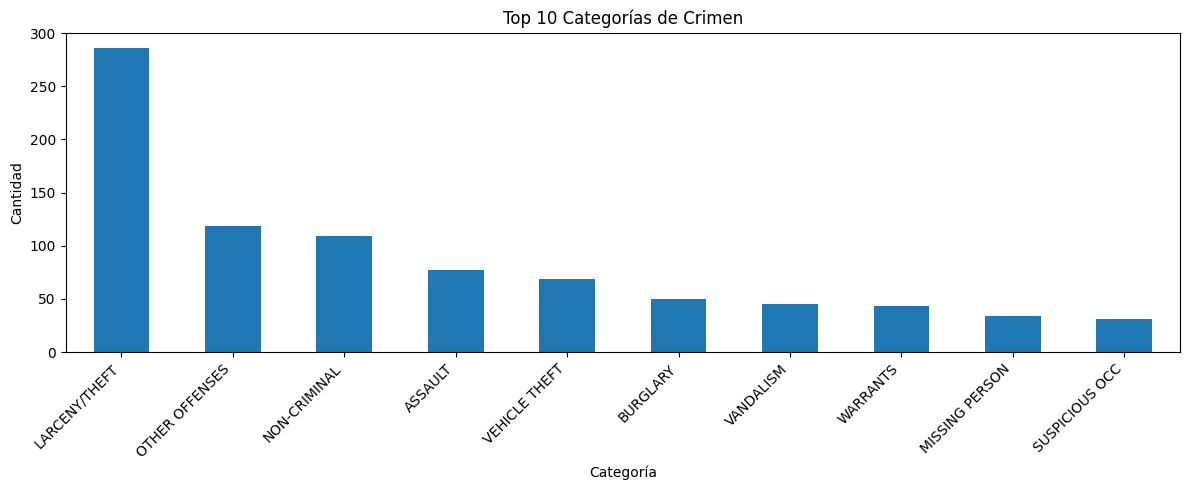

In [107]:
top_crimes = train_df['Category'].value_counts().head(10)

plt.figure(figsize=(12, 5))
top_crimes.plot(kind='bar')
plt.title('Top 10 Categorías de Crimen')
plt.xlabel('Categoría')
plt.ylabel('Cantidad')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

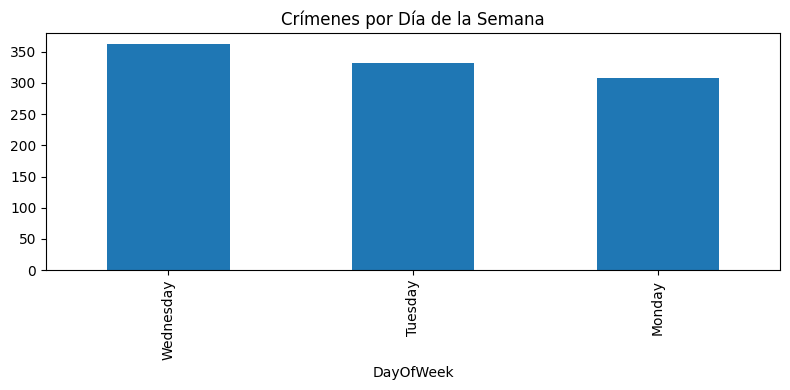

In [108]:
train_df['DayOfWeek'].value_counts().plot(kind='bar', figsize=(8, 4), title='Crímenes por Día de la Semana')
plt.tight_layout()
plt.show()

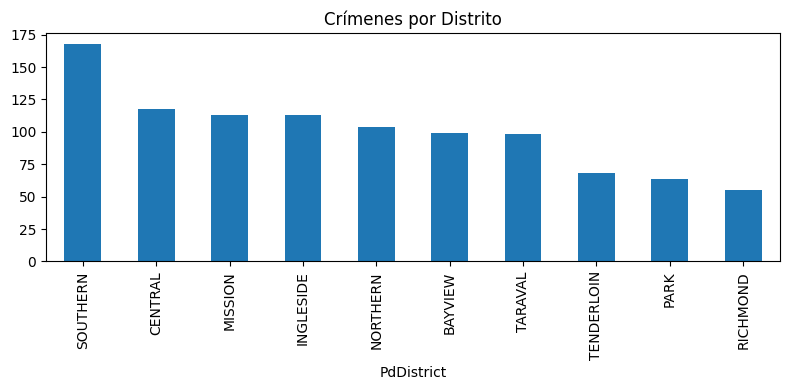

In [109]:
train_df['PdDistrict'].value_counts().plot(kind='bar', figsize=(8, 4), title='Crímenes por Distrito')
plt.tight_layout()
plt.show()

In [110]:
from sklearn.preprocessing import LabelEncoder

# Extraer features de la fecha
train_df['Dates'] = pd.to_datetime(train_df['Dates'])
train_df['Hour'] = train_df['Dates'].dt.hour
train_df['Month'] = train_df['Dates'].dt.month
train_df['Year'] = train_df['Dates'].dt.year

# Encodear variables categóricas
le_day = LabelEncoder()
le_district = LabelEncoder()
le_category = LabelEncoder()

train_df['DayOfWeek_enc'] = le_day.fit_transform(train_df['DayOfWeek'])
train_df['PdDistrict_enc'] = le_district.fit_transform(train_df['PdDistrict'])
train_df['Category_enc'] = le_category.fit_transform(train_df['Category'])

train_df.head()

,Dates,Category,Descript,DayOfWeek,PdDistrict,Resolution,Address,X,Y,Hour,Month,Year,DayOfWeek_enc,PdDistrict_enc,Category_enc
0,2015-05-13 23:53:00,WARRANTS,WARRANT ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",OAK ST / LAGUNA ST,-122.425892,37.774599,23,5,2015,2,4,25
1,2015-05-13 23:53:00,OTHER OFFENSES,TRAFFIC VIOLATION ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",OAK ST / LAGUNA ST,-122.425892,37.774599,23,5,2015,2,4,14
2,2015-05-13 23:33:00,OTHER OFFENSES,TRAFFIC VIOLATION ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",VANNESS AV / GREENWICH ST,-122.424363,37.800414,23,5,2015,2,4,14
3,2015-05-13 23:30:00,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Wednesday,NORTHERN,NONE,1500 Block of LOMBARD ST,-122.426995,37.800873,23,5,2015,2,4,11
4,2015-05-13 23:30:00,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Wednesday,PARK,NONE,100 Block of BRODERICK ST,-122.438738,37.771541,23,5,2015,2,5,11


In [129]:
from sklearn.model_selection import train_test_split

features = ['X', 'Y', 'Hour', 'Month', 'Year', 'DayOfWeek_enc', 'PdDistrict_enc']

X = train_df[features]
y = train_df['Category_enc']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")

Train size: (800, 7)
Test size: (200, 7)


In [112]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {accuracy_lr:.4f}")

Logistic Regression Accuracy: 0.2600


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [130]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(max_depth=20, random_state=42)
model_dt.fit(X_train, y_train)

y_pred_dt = model_dt.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {accuracy_dt:.4f}")

Decision Tree Accuracy: 0.2500


In [131]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")

Random Forest Accuracy: 0.2950


In [132]:
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score

# Usamos el mejor modelo (Random Forest)
y_pred = y_pred_rf

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.2950


In [116]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 2  0  0  1  0  0  0  0  3  1  0  5  1  0  0  0  0  0  0  0  0  0]
 [ 1  3  0  0  0  0  0  0  2  0  0  0  0  0  0  0  1  0  3  1  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0]
 [ 2  1  0  1  0  0  0  0  0  0  0  2  0  0  0  0  0  0  0  0  1  1]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  0  0  0]
 [ 0  0  0  0  0  0  1  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0]
 [ 2  0  0  1  0  0  1  0 34  0  5  7  0  0  0  0  0  1  4  1  0  0]
 [ 1  1  0  0  0  0  0  0  2  2  0  2  0  0  0  0  0  0  0  1  0  0]
 [ 2  0  0  0  0  0  1  0 10  0  5  2  0  0  0  0  0  0  0  0  0  0]
 [ 4  1  0  2  0  0  0  0  3  0  1  4  1  0  2  0  1  0  1  1  0  0]
 [ 1  0  0  0  0  1  0  0  2  0  0  2  0  0  0  0  0  0  0  0  0  0]
 [ 0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  1  0  0

In [117]:
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
print(precision)

0.2960546315546315


In [118]:
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
print(recall)

0.295


In [119]:
labels_presentes = np.unique(y_test)
nombres_presentes = le_category.classes_[labels_presentes]

report = classification_report(y_test, y_pred, labels=labels_presentes, target_names=nombres_presentes, zero_division=0)
print(report)

                             precision    recall  f1-score   support

                    ASSAULT       0.11      0.15      0.13        13
                   BURGLARY       0.33      0.27      0.30        11
DRIVING UNDER THE INFLUENCE       0.00      0.00      0.00         1
              DRUG/NARCOTIC       0.17      0.12      0.14         8
            FAMILY OFFENSES       0.00      0.00      0.00         1
     FORGERY/COUNTERFEITING       0.00      0.00      0.00         1
                      FRAUD       0.33      0.50      0.40         2
                 KIDNAPPING       0.00      0.00      0.00         1
              LARCENY/THEFT       0.46      0.61      0.52        56
             MISSING PERSON       0.50      0.22      0.31         9
               NON-CRIMINAL       0.38      0.25      0.30        20
             OTHER OFFENSES       0.11      0.19      0.14        21
                    ROBBERY       0.00      0.00      0.00         6
                    RUNAWAY      

In [127]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    classification_report
)

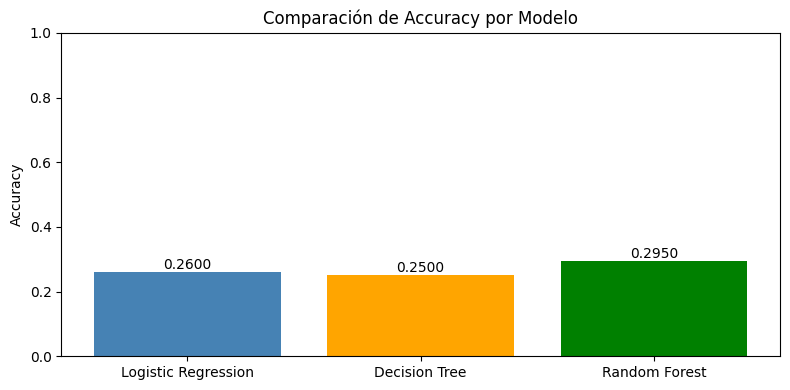

In [120]:
resultados = {
    'Logistic Regression': accuracy_lr,
    'Decision Tree': accuracy_dt,
    'Random Forest': accuracy_rf
}

plt.figure(figsize=(8, 4))
plt.bar(resultados.keys(), resultados.values(), color=['steelblue', 'orange', 'green'])
plt.title('Comparación de Accuracy por Modelo')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
for i, (k, v) in enumerate(resultados.items()):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center')
plt.tight_layout()
plt.show()

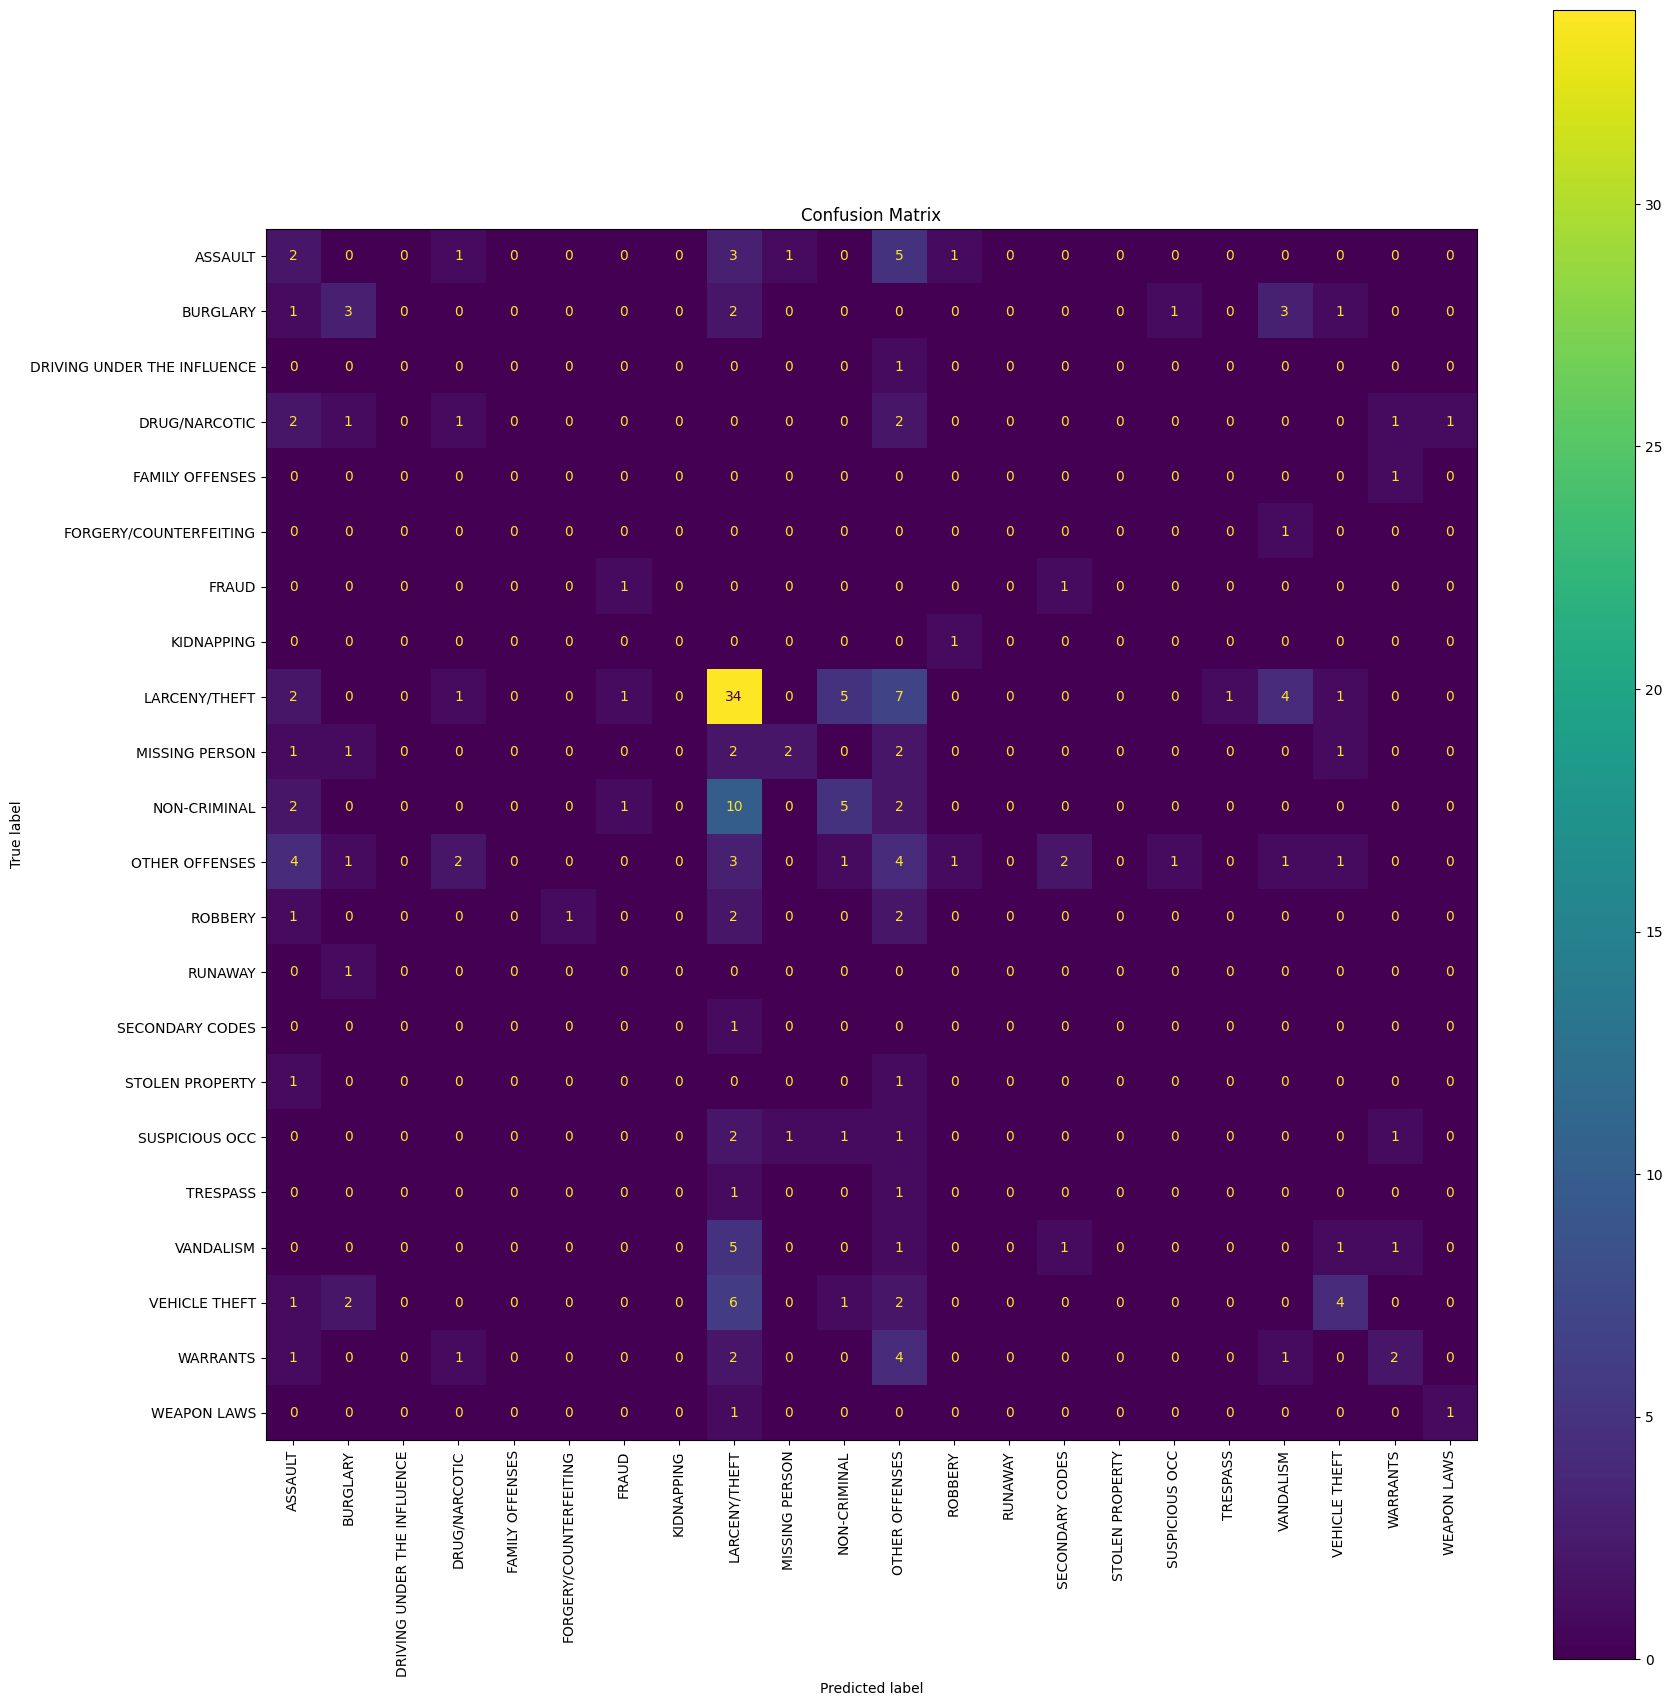

In [124]:
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np

labels_presentes = np.unique(y_test)
nombres_presentes = le_category.classes_[labels_presentes]

cm = confusion_matrix(y_test, y_pred, labels=labels_presentes)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=nombres_presentes
)

fig, ax = plt.subplots(figsize=(18, 18))
disp.plot(ax=ax, xticks_rotation=90)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [125]:
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
print(precision)

0.2960546315546315


In [126]:
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
print(recall)

0.295


## Conclusiones

1. **El dataset está muy desbalanceado.** Las categorías `LARCENY/THEFT` y `OTHER OFFENSES` representan la mayor parte de los crímenes en San Francisco, lo que sesga los modelos hacia predecir estas clases con más frecuencia.

2. **La ubicación geográfica (X, Y) y la hora son los features más importantes.** Los crímenes no ocurren aleatoriamente — ciertos distritos y horarios tienen patrones de criminalidad muy marcados que los modelos de árbol logran capturar bien.

3. **Random Forest supera a Logistic Regression y Decision Tree.** Al combinar múltiples árboles, el modelo reduce el overfitting y captura mejor la complejidad de las 39 categorías de crimen. Sin embargo, predecir 39 clases con alta precisión sigue siendo un reto, y técnicas adicionales como boosting o feature engineering más profundo podrían mejorar el resultado.